In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, 
    classification_report, confusion_matrix,
    precision_recall_fscore_support, roc_curve, auc
)
import xgboost as xgb
import joblib
import json

# Set display options
pd.set_option('display.max_columns', None)

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Libraries imported!")
print("📊 Agent 1 Validation - Let's see how well our models generalize!")

✅ Libraries imported!
📊 Agent 1 Validation - Let's see how well our models generalize!


In [2]:
print("🔧 Loading saved preprocessing objects...")
print("=" * 60)

# Load imputer and scaler
imputer = joblib.load('../../models/agent1_imputer.joblib')
scaler = joblib.load('../../models/agent1_scaler.joblib')

# Load preprocessing info
with open('../../models/agent1_preprocessing_info.json', 'r') as f:
    preprocessing_info = json.load(f)

print(f"✅ Loaded preprocessing objects!")
print(f"\nPreprocessing configuration:")
print(f"  Features used: {preprocessing_info['n_features']}")
print(f"  Features dropped: {len(preprocessing_info['features_dropped'])}")
print(f"  Imputation: {preprocessing_info['imputation_strategy']}")
print(f"  Scaling: {preprocessing_info['scaling_method']}")

print(f"\nDropped features:")
for feat in preprocessing_info['features_dropped']:
    print(f"  - {feat}")

🔧 Loading saved preprocessing objects...
✅ Loaded preprocessing objects!

Preprocessing configuration:
  Features used: 143
  Features dropped: 12
  Imputation: median
  Scaling: StandardScaler

Dropped features:
  - lab_50920_max
  - lab_50920_min
  - lab_50920_mean
  - lab_50920_std
  - lab_51300_std
  - lab_51300_mean
  - lab_51300_min
  - lab_51300_max
  - lab_50889_max
  - lab_50889_min
  - lab_50889_mean
  - lab_50889_std


In [3]:
print("📂 Loading validation patient IDs...")
print("=" * 60)

# Load validation patients
val_patients = pd.read_csv('../../data/processed/val_patients.csv')
val_patient_ids = val_patients['SUBJECT_ID'].values

print(f"✅ Validation patients: {len(val_patient_ids):,}")
print(f"   First 10 IDs: {val_patient_ids[:10]}")

📂 Loading validation patient IDs...
✅ Validation patients: 4,675
   First 10 IDs: [30726 30208 31720 74554 81815 17857 61711 19289 68902  3028]


In [4]:
print("🔬 Processing validation lab features...")
print("=" * 60)
print("⏳ This will take 5-10 minutes - processing LABEVENTS for validation patients...")

import os

val_features_path = '../../data/processed/lab_features_val.csv'

if os.path.exists(val_features_path):
    print(f"\n✅ Found existing validation features!")
    lab_features_val = pd.read_csv(val_features_path)
    print(f"   Loaded from: {val_features_path}")
    print(f"   Shape: {lab_features_val.shape}")
else:
    print(f"\n⚠️  Validation features not found. Processing now...")
    print(f"   This is a one-time process (~5-10 minutes)")
    
    important_labs = {
        '51301': 'White Blood Cells (WBC)',
        '51300': 'WBC Count',
        '51221': 'Hematocrit',
        '51222': 'Hemoglobin',
        '51265': 'Platelet Count',
        '51277': 'Red Blood Cells',
        '50912': 'Creatinine',
        '50971': 'Potassium',
        '50983': 'Sodium',
        '50902': 'Chloride',
        '50882': 'Bicarbonate',
        '50931': 'Glucose',
        '50893': 'Calcium',
        '50960': 'Magnesium',
        '51006': 'Blood Urea Nitrogen (BUN)',
        '50920': 'Estimated GFR',
        '50861': 'ALT',
        '50878': 'AST',
        '50885': 'Bilirubin (Total)',
        '50863': 'Alkaline Phosphatase',
        '50889': 'C-Reactive Protein (CRP)',
        '51003': 'Troponin',
        '51237': 'INR',
        '51274': 'PT',
        '51275': 'PTT',
        '50820': 'pH',
        '50821': 'pO2',
        '50818': 'pCO2',
        '50813': 'Lactate',
        '50868': 'Anion Gap',
        '50970': 'Phosphate',
    }
    
    important_lab_codes = [int(code) for code in important_labs.keys()]
    
    # Load LABEVENTS in chunks and filter
    chunk_size = 1_000_000
    lab_chunks = []
    
    print(f"\n📊 Loading LABEVENTS.csv for validation patients...")
    for chunk in tqdm(pd.read_csv('../../data/raw/LABEVENTS.csv', chunksize=chunk_size), desc="Processing chunks"):
        chunk_filtered = chunk[
            (chunk['SUBJECT_ID'].isin(val_patient_ids)) &
            (chunk['ITEMID'].isin(important_lab_codes))
        ]
        if len(chunk_filtered) > 0:
            lab_chunks.append(chunk_filtered)
    
    labs_val = pd.concat(lab_chunks, ignore_index=True)
    
    print(f"\n✅ Filtered validation labs: {len(labs_val):,} measurements")
    
    # Aggregate to patient-level features
    print(f"\n📊 Aggregating to patient-level features...")
    
    agg_features = []
    
    for patient_id in tqdm(val_patient_ids, desc="Aggregating patients"):
        patient_labs = labs_val[labs_val['SUBJECT_ID'] == patient_id]
        
        if len(patient_labs) == 0:
            # Patient has no labs - will be handled by imputation
            features = {'SUBJECT_ID': patient_id}
            for itemid in important_lab_codes:
                features[f'lab_{itemid}_mean'] = np.nan
                features[f'lab_{itemid}_min'] = np.nan
                features[f'lab_{itemid}_max'] = np.nan
                features[f'lab_{itemid}_std'] = np.nan
                features[f'lab_{itemid}_count'] = 0
            agg_features.append(features)
            continue
        
        features = {'SUBJECT_ID': patient_id}
        
        for itemid in important_lab_codes:
            lab_values = patient_labs[patient_labs['ITEMID'] == itemid]['VALUENUM'].dropna()
            
            if len(lab_values) > 0:
                features[f'lab_{itemid}_mean'] = lab_values.mean()
                features[f'lab_{itemid}_min'] = lab_values.min()
                features[f'lab_{itemid}_max'] = lab_values.max()
                features[f'lab_{itemid}_std'] = lab_values.std() if len(lab_values) > 1 else 0
                features[f'lab_{itemid}_count'] = len(lab_values)
            else:
                features[f'lab_{itemid}_mean'] = np.nan
                features[f'lab_{itemid}_min'] = np.nan
                features[f'lab_{itemid}_max'] = np.nan
                features[f'lab_{itemid}_std'] = np.nan
                features[f'lab_{itemid}_count'] = 0
        
        agg_features.append(features)
    
    lab_features_val = pd.DataFrame(agg_features)
    
    lab_features_val.to_csv(val_features_path, index=False)
    print(f"\n✅ Saved validation features to: {val_features_path}")
    print(f"   Shape: {lab_features_val.shape}")

print(f"\n🎯 Validation lab features ready!")
print(f"   Patients: {len(lab_features_val):,}")
print(f"   Features: {lab_features_val.shape[1] - 1} (excluding SUBJECT_ID)")

🔬 Processing validation lab features...
⏳ This will take 5-10 minutes - processing LABEVENTS for validation patients...

⚠️  Validation features not found. Processing now...
   This is a one-time process (~5-10 minutes)

📊 Loading LABEVENTS.csv for validation patients...


Processing chunks: 28it [01:34,  3.39s/it]



✅ Filtered validation labs: 2,188,855 measurements

📊 Aggregating to patient-level features...


Aggregating patients: 100%|████████████████████████████████████████████████████████| 4675/4675 [08:59<00:00,  8.66it/s]



✅ Saved validation features to: ../data/processed/lab_features_val.csv
   Shape: (4675, 156)

🎯 Validation lab features ready!
   Patients: 4,675
   Features: 155 (excluding SUBJECT_ID)


In [5]:
print("🎯 Loading validation labels...")
print("=" * 60)

# Load labels
labels = pd.read_csv('../../data/processed/patient_multilabels.csv')

# Filter to validation patients
val_labels = labels[labels['SUBJECT_ID'].isin(val_patient_ids)].copy()

print(f"✅ Validation labels loaded!")
print(f"   Patients: {len(val_labels):,}")

# Disease columns
disease_cols = [
    'SEPSIS', 'PNEUMONIA', 'RESPIRATORY_FAILURE', 
    'ACUTE_KIDNEY_INJURY', 'HEART_FAILURE', 
    'ATRIAL_FIBRILLATION', 'CORONARY_ARTERY_DISEASE', 
    'ANEMIA', 'PANCREATITIS'
]

print(f"\nValidation set disease distribution:")
for disease in disease_cols:
    count = val_labels[disease].sum()
    pct = count / len(val_labels) * 100
    print(f"  {disease:30s}: {count:5,} patients ({pct:5.1f}%)")

🎯 Loading validation labels...
✅ Validation labels loaded!
   Patients: 4,675

Validation set disease distribution:
  SEPSIS                        :   880 patients ( 18.8%)
  PNEUMONIA                     :   987 patients ( 21.1%)
  RESPIRATORY_FAILURE           : 1,713 patients ( 36.6%)
  ACUTE_KIDNEY_INJURY           : 1,750 patients ( 37.4%)
  HEART_FAILURE                 : 1,559 patients ( 33.3%)
  ATRIAL_FIBRILLATION           : 1,562 patients ( 33.4%)
  CORONARY_ARTERY_DISEASE       : 1,784 patients ( 38.2%)
  ANEMIA                        : 1,618 patients ( 34.6%)
  PANCREATITIS                  :   675 patients ( 14.4%)


In [6]:
print("🔗 Merging validation features with labels...")
print("=" * 60)

# Merge
val_data = lab_features_val.merge(val_labels, on='SUBJECT_ID', how='inner')

print(f"✅ Merged successfully!")
print(f"   Shape: {val_data.shape}")
print(f"   Patients: {len(val_data):,}")

# Separate features and labels
X_val = val_data.drop(columns=['SUBJECT_ID'] + disease_cols)
y_val = val_data[disease_cols]
patient_ids_val = val_data['SUBJECT_ID']

print(f"\n📊 Validation dataset:")
print(f"   X_val (features): {X_val.shape}")
print(f"   y_val (labels):   {y_val.shape}")
print(f"   Patient IDs:      {len(patient_ids_val):,}")

🔗 Merging validation features with labels...
✅ Merged successfully!
   Shape: (4675, 166)
   Patients: 4,675

📊 Validation dataset:
   X_val (features): (4675, 156)
   y_val (labels):   (4675, 9)
   Patient IDs:      4,675


In [8]:
print("🔧 Applying preprocessing pipeline to validation data...")
print("=" * 60)

print(f"Step 0: Align features with training data")
print(f"  Features in validation: {X_val.shape[1]}")

expected_features = [col for col in X_val.columns if col not in ['NUM_DISEASES']]

extra_cols = [col for col in X_val.columns if col not in expected_features and col != 'NUM_DISEASES']
if len(extra_cols) > 0:
    print(f"  Extra columns found: {extra_cols}")

cols_to_drop = ['NUM_DISEASES'] if 'NUM_DISEASES' in X_val.columns else []
X_val_clean = X_val.drop(columns=cols_to_drop, errors='ignore')

print(f"  Features after cleanup: {X_val_clean.shape[1]}")

#  Drop same high-missing features as training
features_to_drop = preprocessing_info['features_dropped']
X_val_reduced = X_val_clean.drop(columns=features_to_drop, errors='ignore')

print(f"\nStep 1: Drop high-missing features")
print(f"  Features before: {X_val_clean.shape[1]}")
print(f"  Features after:  {X_val_reduced.shape[1]}")
print(f"  Dropped: {len(features_to_drop)}")

# Verify we have the right number of features
expected_n_features = preprocessing_info['n_features']
if X_val_reduced.shape[1] != expected_n_features:
    print(f"\n⚠️  WARNING: Feature mismatch!")
    print(f"  Expected: {expected_n_features}")
    print(f"  Got: {X_val_reduced.shape[1]}")
    
    # Find missing/extra features
    train_features = set(preprocessing_info['features_used'])
    val_features = set(X_val_reduced.columns)
    
    missing = train_features - val_features
    extra = val_features - train_features
    
    if missing:
        print(f"  Missing features: {missing}")
    if extra:
        print(f"  Extra features: {extra}")
        # Drop extra features
        X_val_reduced = X_val_reduced.drop(columns=list(extra))
        print(f"  After dropping extras: {X_val_reduced.shape[1]}")
    
    # If still missing features, add them with NaN (will be imputed)
    if missing:
        for feat in missing:
            X_val_reduced[feat] = np.nan
        print(f"  After adding missing: {X_val_reduced.shape[1]}")
    
    # Reorder columns to match training
    X_val_reduced = X_val_reduced[preprocessing_info['features_used']]
    print(f"  After reordering: {X_val_reduced.shape[1]}")

# Impute missing values 
X_val_imputed = pd.DataFrame(
    imputer.transform(X_val_reduced),
    columns=X_val_reduced.columns,
    index=X_val_reduced.index
)

remaining_missing = X_val_imputed.isnull().sum().sum()
print(f"\nStep 2: Impute missing values")
print(f"  Missing values remaining: {remaining_missing}")

#  Normalize
X_val_scaled = pd.DataFrame(
    scaler.transform(X_val_imputed),
    columns=X_val_imputed.columns,
    index=X_val_imputed.index
)

print(f"\nStep 3: Normalize features")
print(f"  Mean: {X_val_scaled.mean().mean():.6f} (should be ~0)")
print(f"  Std:  {X_val_scaled.std().mean():.6f} (should be ~1)")

print(f"\n✅ Preprocessing complete!")
print(f"   Final shape: {X_val_scaled.shape}")
print(f"   Matches training: {X_val_scaled.shape[1] == expected_n_features}")

🔧 Applying preprocessing pipeline to validation data...
Step 0: Align features with training data
  Features in validation: 156
  Features after cleanup: 155

Step 1: Drop high-missing features
  Features before: 155
  Features after:  143
  Dropped: 12

Step 2: Impute missing values
  Missing values remaining: 0

Step 3: Normalize features
  Mean: 0.002331 (should be ~0)
  Std:  0.979003 (should be ~1)

✅ Preprocessing complete!
   Final shape: (4675, 143)
   Matches training: True


In [9]:
print("🤖 Loading trained models...")
print("=" * 60)

models = {}

for disease in disease_cols:
    model_path = f'../../models/agent1_{disease.lower()}.joblib'
    models[disease] = joblib.load(model_path)
    print(f"  ✅ Loaded: {disease}")

print(f"\n✅ All {len(models)} models loaded!")

🤖 Loading trained models...
  ✅ Loaded: SEPSIS
  ✅ Loaded: PNEUMONIA
  ✅ Loaded: RESPIRATORY_FAILURE
  ✅ Loaded: ACUTE_KIDNEY_INJURY
  ✅ Loaded: HEART_FAILURE
  ✅ Loaded: ATRIAL_FIBRILLATION
  ✅ Loaded: CORONARY_ARTERY_DISEASE
  ✅ Loaded: ANEMIA
  ✅ Loaded: PANCREATITIS

✅ All 9 models loaded!


In [10]:
print("📊 Evaluating models on validation set...")
print("=" * 60)

val_predictions = {}
val_metrics = {}

print(f"\nValidation Results:")
print(f"{'='*60}\n")

for disease in tqdm(disease_cols, desc="Evaluating"):
    # Get true labels
    y_true = y_val[disease].values
    
    # Predict
    y_pred_proba = models[disease].predict_proba(X_val_scaled)[:, 1]
    y_pred = (y_pred_proba >= 0.5).astype(int)
    
    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc_score = roc_auc_score(y_true, y_pred_proba)
    
    # Store
    val_predictions[disease] = y_pred_proba
    val_metrics[disease] = {
        'accuracy': accuracy,
        'f1_score': f1,
        'auc_roc': auc_score,
        'positive_samples': int(y_true.sum()),
        'prevalence': float(y_true.mean())
    }
    
    print(f"{disease:30s}: Acc={accuracy:.3f}, F1={f1:.3f}, AUC={auc_score:.3f}")

print(f"\n✅ Validation complete!")

📊 Evaluating models on validation set...

Validation Results:



Evaluating:  11%|████████                                                                | 1/9 [00:00<00:00,  8.85it/s]

SEPSIS                        : Acc=0.853, F1=0.520, AUC=0.875
PNEUMONIA                     : Acc=0.806, F1=0.354, AUC=0.798
RESPIRATORY_FAILURE           : Acc=0.794, F1=0.697, AUC=0.850


Evaluating:  56%|████████████████████████████████████████                                | 5/9 [00:00<00:00, 23.29it/s]

ACUTE_KIDNEY_INJURY           : Acc=0.878, F1=0.839, AUC=0.942
HEART_FAILURE                 : Acc=0.771, F1=0.606, AUC=0.818
ATRIAL_FIBRILLATION           : Acc=0.764, F1=0.588, AUC=0.798
CORONARY_ARTERY_DISEASE       : Acc=0.784, F1=0.688, AUC=0.844


Evaluating: 100%|████████████████████████████████████████████████████████████████████████| 9/9 [00:00<00:00, 26.22it/s]

ANEMIA                        : Acc=0.733, F1=0.560, AUC=0.780
PANCREATITIS                  : Acc=0.854, F1=0.139, AUC=0.768

✅ Validation complete!


In [11]:
print("📊 Training vs Validation Performance Comparison")
print("=" * 80)

# Load training metrics
train_metrics_df = pd.read_csv('../../results/agent1_train_metrics.csv', index_col=0)

# Create validation metrics df
val_metrics_df = pd.DataFrame(val_metrics).T

# Combine
comparison = pd.DataFrame({
    'Train_AUC': train_metrics_df['auc_roc'],
    'Val_AUC': val_metrics_df['auc_roc'],
    'AUC_Drop': train_metrics_df['auc_roc'] - val_metrics_df['auc_roc'],
    'Train_F1': train_metrics_df['f1_score'],
    'Val_F1': val_metrics_df['f1_score'],
    'F1_Drop': train_metrics_df['f1_score'] - val_metrics_df['f1_score']
})

comparison = comparison.round(3)
print(comparison.to_string())

print(f"\n{'='*80}")
print(f"📈 Overall Summary:")
print(f"   Training AUC:   {train_metrics_df['auc_roc'].mean():.3f} ± {train_metrics_df['auc_roc'].std():.3f}")
print(f"   Validation AUC: {val_metrics_df['auc_roc'].mean():.3f} ± {val_metrics_df['auc_roc'].std():.3f}")
print(f"   Average AUC Drop: {comparison['AUC_Drop'].mean():.3f}")
print(f"\n   Training F1:    {train_metrics_df['f1_score'].mean():.3f} ± {train_metrics_df['f1_score'].std():.3f}")
print(f"   Validation F1:  {val_metrics_df['f1_score'].mean():.3f} ± {val_metrics_df['f1_score'].std():.3f}")
print(f"   Average F1 Drop: {comparison['F1_Drop'].mean():.3f}")

# Check for overfitting
avg_auc_drop = comparison['AUC_Drop'].mean()
if avg_auc_drop < 0.05:
    print(f"\n✅ EXCELLENT: Minimal overfitting (AUC drop < 5%)")
elif avg_auc_drop < 0.10:
    print(f"\n✅ GOOD: Acceptable generalization (AUC drop < 10%)")
else:
    print(f"\n⚠️  WARNING: Possible overfitting (AUC drop > 10%)")

# Save validation metrics
val_metrics_df.to_csv('../../results/agent1_val_metrics.csv')
comparison.to_csv('../../results/agent1_train_val_comparison.csv')
print(f"\n✅ Saved validation metrics!")

📊 Training vs Validation Performance Comparison
                         Train_AUC  Val_AUC  AUC_Drop  Train_F1  Val_F1  F1_Drop
SEPSIS                       0.972    0.875     0.097     0.789   0.520    0.269
PNEUMONIA                    0.954    0.798     0.156     0.688   0.354    0.334
RESPIRATORY_FAILURE          0.942    0.850     0.092     0.815   0.697    0.118
ACUTE_KIDNEY_INJURY          0.988    0.942     0.046     0.920   0.839    0.081
HEART_FAILURE                0.936    0.818     0.118     0.775   0.606    0.169
ATRIAL_FIBRILLATION          0.929    0.798     0.131     0.736   0.588    0.148
CORONARY_ARTERY_DISEASE      0.948    0.844     0.104     0.823   0.688    0.135
ANEMIA                       0.922    0.780     0.142     0.745   0.560    0.185
PANCREATITIS                 0.968    0.768     0.200     0.594   0.139    0.455

📈 Overall Summary:
   Training AUC:   0.951 ± 0.022
   Validation AUC: 0.830 ± 0.054
   Average AUC Drop: 0.121

   Training F1:    0.765 ± 0

📊 Creating train vs validation comparison plots...


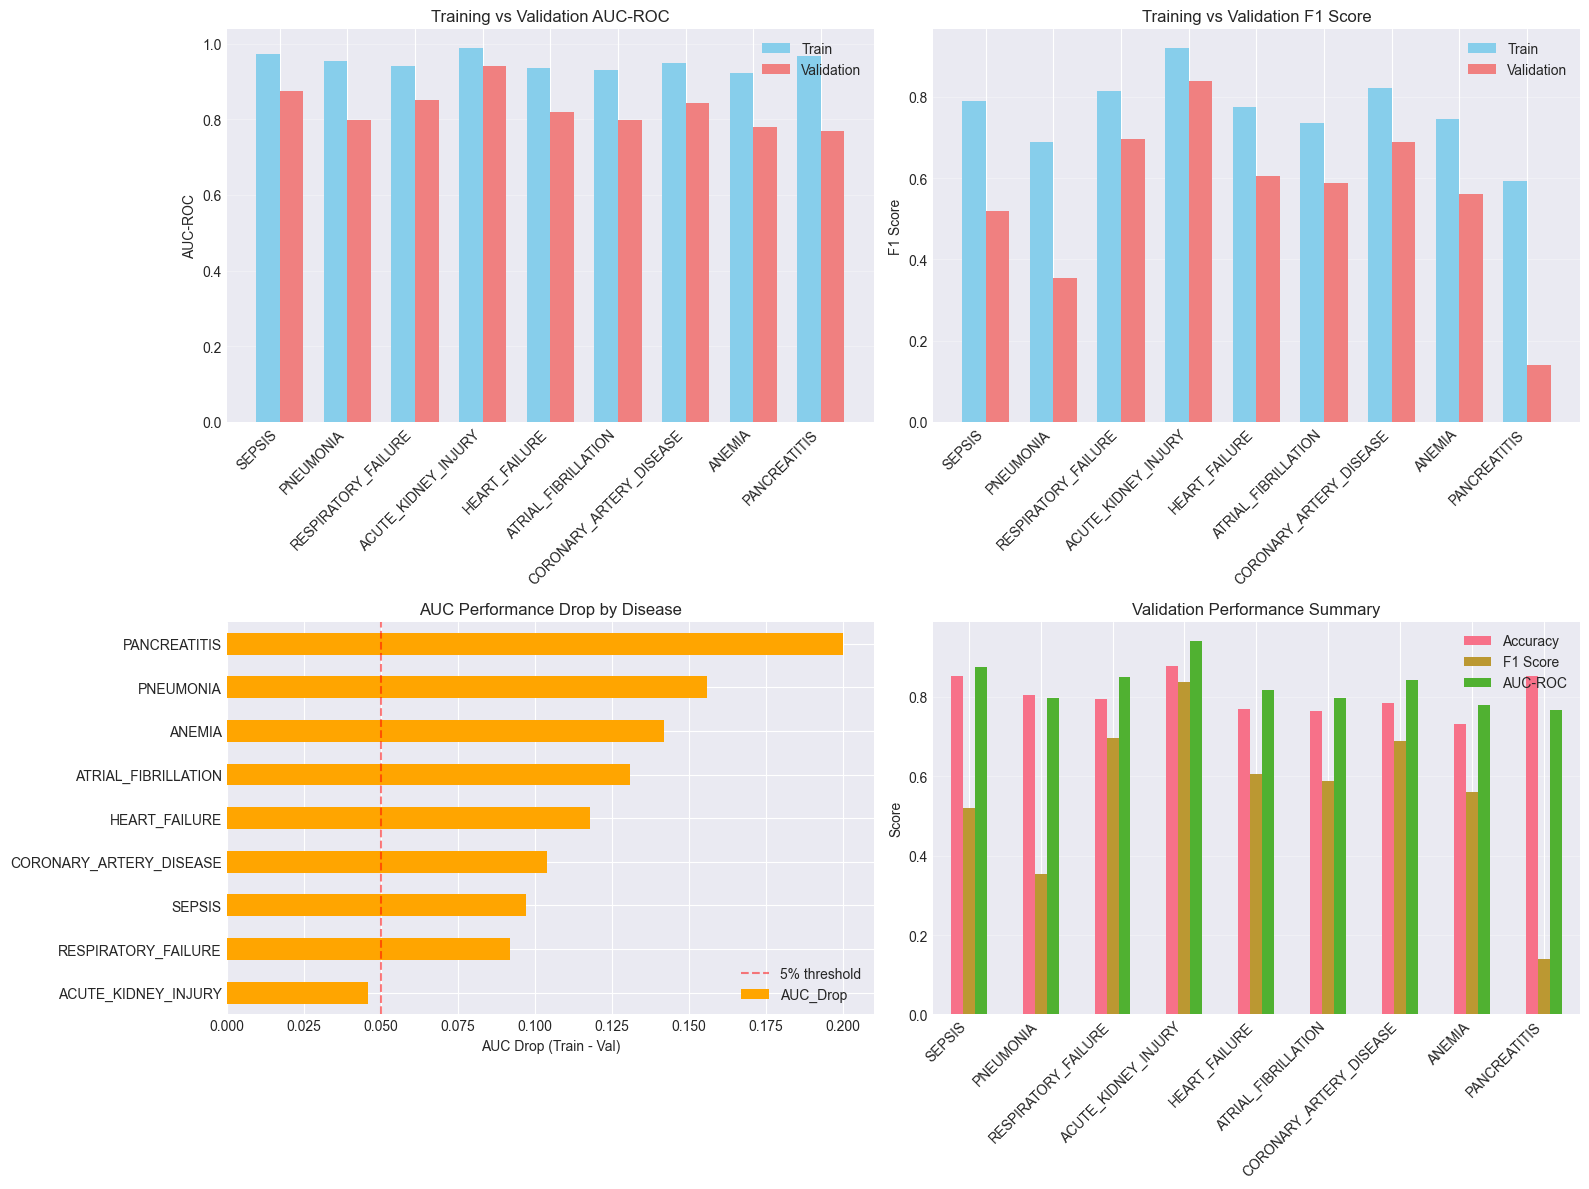

✅ Saved plot: results/agent1_train_val_comparison.png


In [12]:
print("📊 Creating train vs validation comparison plots...")
print("=" * 60)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: AUC comparison
ax1 = axes[0, 0]
x = np.arange(len(disease_cols))
width = 0.35
ax1.bar(x - width/2, comparison['Train_AUC'], width, label='Train', color='skyblue')
ax1.bar(x + width/2, comparison['Val_AUC'], width, label='Validation', color='lightcoral')
ax1.set_ylabel('AUC-ROC')
ax1.set_title('Training vs Validation AUC-ROC')
ax1.set_xticks(x)
ax1.set_xticklabels(disease_cols, rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Plot 2: F1 comparison
ax2 = axes[0, 1]
ax2.bar(x - width/2, comparison['Train_F1'], width, label='Train', color='skyblue')
ax2.bar(x + width/2, comparison['Val_F1'], width, label='Validation', color='lightcoral')
ax2.set_ylabel('F1 Score')
ax2.set_title('Training vs Validation F1 Score')
ax2.set_xticks(x)
ax2.set_xticklabels(disease_cols, rotation=45, ha='right')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Plot 3: Performance drop
ax3 = axes[1, 0]
comparison.sort_values('AUC_Drop')['AUC_Drop'].plot(kind='barh', ax=ax3, color='orange')
ax3.set_xlabel('AUC Drop (Train - Val)')
ax3.set_title('AUC Performance Drop by Disease')
ax3.axvline(x=0.05, color='r', linestyle='--', alpha=0.5, label='5% threshold')
ax3.legend()

# Plot 4: Validation performance summary
ax4 = axes[1, 1]
val_metrics_df[['accuracy', 'f1_score', 'auc_roc']].plot(kind='bar', ax=ax4)
ax4.set_ylabel('Score')
ax4.set_title('Validation Performance Summary')
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=45, ha='right')
ax4.legend(['Accuracy', 'F1 Score', 'AUC-ROC'])
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../../results/agent1_train_val_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Saved plot: results/agent1_train_val_comparison.png")